In [1]:
pip install pandas matplotlib seaborn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 8.1/8.1 MB 50.2 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 64.3 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ---------------------------------------- 7.0/7.0 MB 72.0 MB/s  0:00:00

   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   --------------- ------------------------ 3/8 [fonttools]
   --------------- ------------------------ 3/8 [fonttools]
   --------------- ------------------------ 3/8 [fonttools]
   --------------- ------------------------ 3/8 [fonttools]
   --------------- ------------------------ 3/8 [fonttools]
   --------------- -----------------------

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")


All libraries loaded successfully!


In [3]:
df = pd.read_csv('../data/retail_sales.csv')
print(df.shape)
print(df.head())

(9800, 18)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156   8/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156   8/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688   12/6/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID 

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

print(df['Order Date'].dtype)
print(df['Order Date'].min(), "to", df['Order Date'].max())

datetime64[us]
2015-01-03 00:00:00 to 2018-12-30 00:00:00


In [7]:
df['Year'] = df['Order Date'].dt.year

revenue_by_year = df.groupby('Year')['Sales'].sum().reset_index()
print(revenue_by_year)

   Year        Sales
0  2015  479856.2081
1  2016  459436.0054
2  2017  600192.5500
3  2018  722052.0192


C:\Users\mouni\AppData\Local\Temp\ipykernel_12496\3737816746.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_year, x='Year', y='Sales', palette='blues_d')


ValueError: 'blues_d' is not a valid palette name

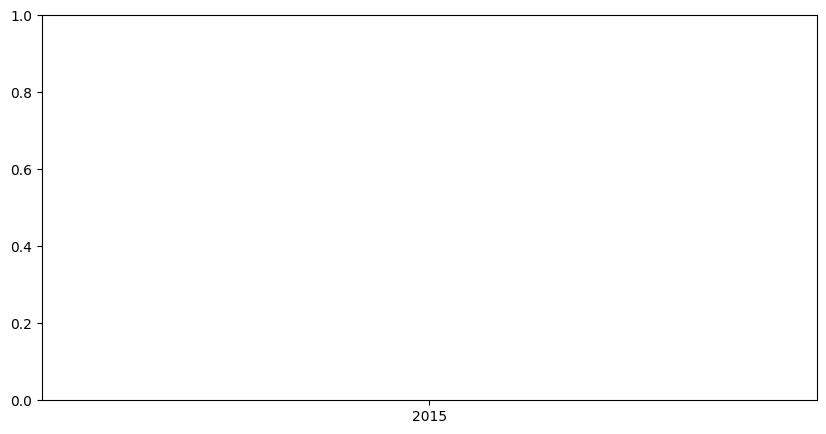

In [8]:
plt.figure(figsize=(10, 5))
sns.barplot(data=revenue_by_year, x='Year', y='Sales', palette='blues_d')
plt.title('Total Revenue by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

C:\Users\mouni\AppData\Local\Temp\ipykernel_12496\612652843.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_category, x='Category', y='Sales', palette='viridis')


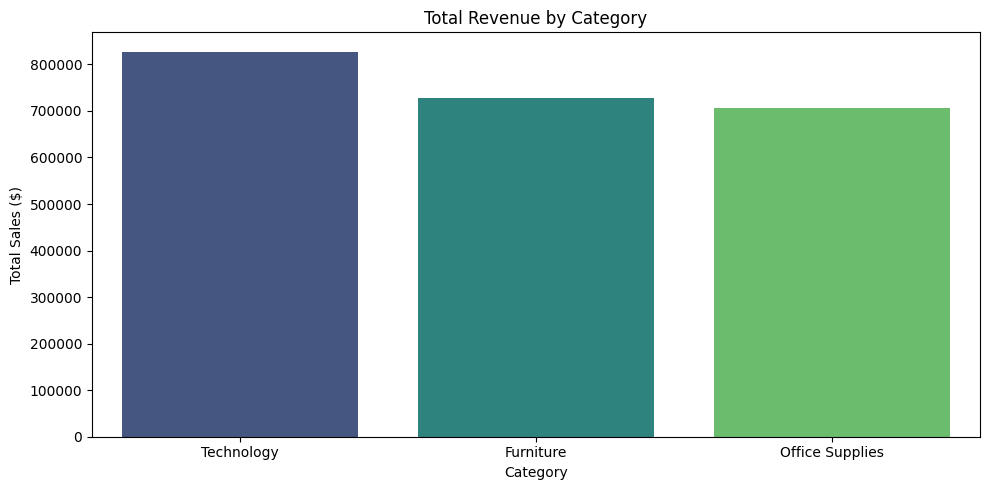

In [9]:
revenue_by_category = df.groupby('Category')['Sales'].sum().reset_index()
revenue_by_category = revenue_by_category.sort_values('Sales', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=revenue_by_category, x='Category', y='Sales', palette='viridis')
plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

C:\Users\mouni\AppData\Local\Temp\ipykernel_12496\1886612007.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_customers, x='Sales', y='Customer Name', palette='rocket')


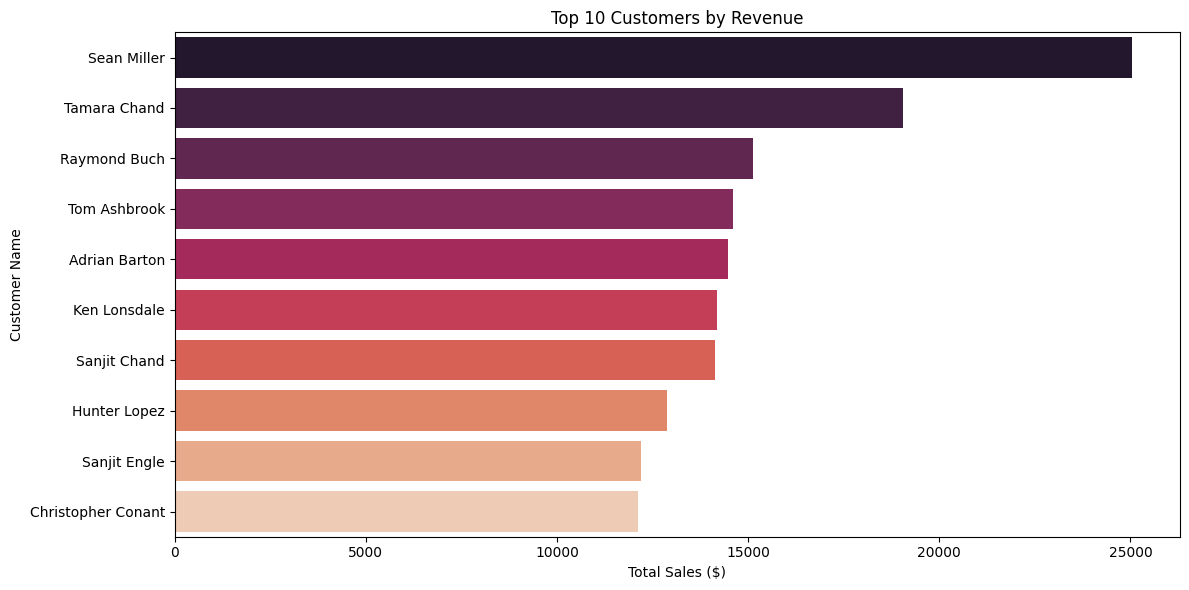

In [10]:
top_customers = df.groupby('Customer Name')['Sales'].sum().reset_index()
top_customers = top_customers.sort_values('Sales', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_customers, x='Sales', y='Customer Name', palette='rocket')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Total Sales ($)')
plt.ylabel('Customer Name')
plt.tight_layout()
plt.show()

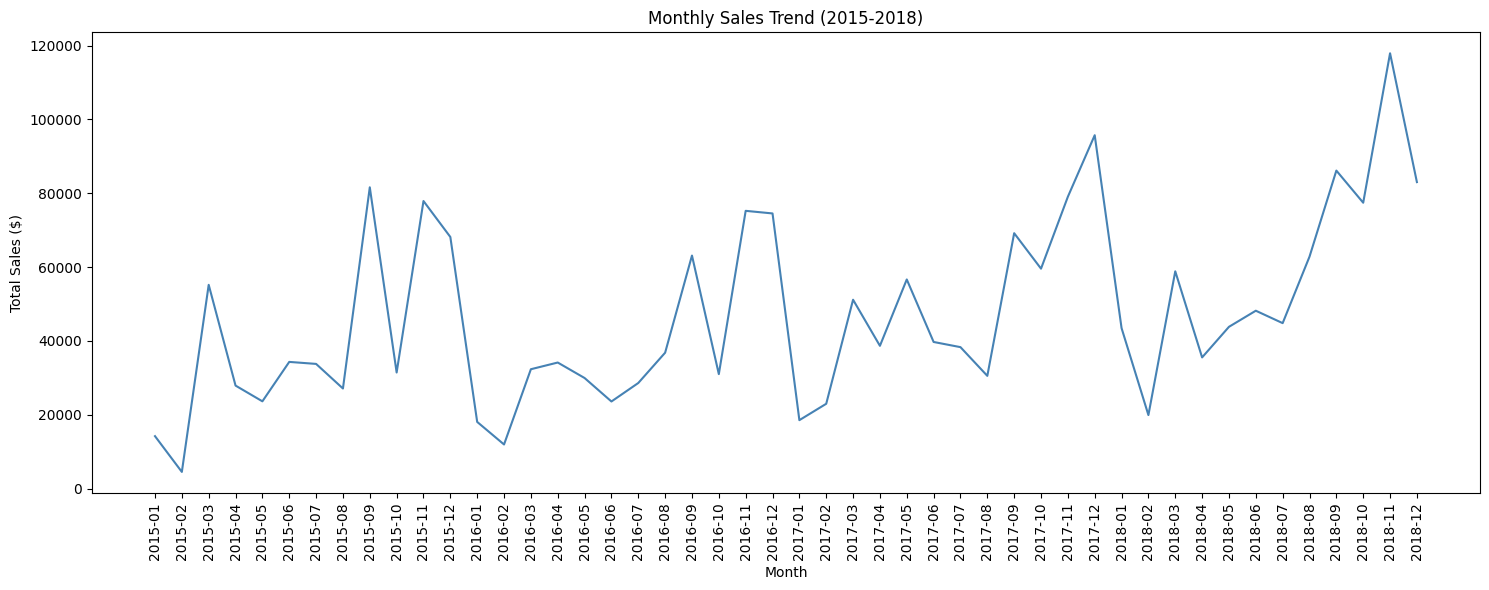

In [11]:
df['YearMonth'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('YearMonth')['Sales'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_sales, x='YearMonth', y='Sales', color='steelblue')
plt.title('Monthly Sales Trend (2015-2018)')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

C:\Users\mouni\AppData\Local\Temp\ipykernel_12496\1459741496.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_region, x='Region', y='Sales', palette='coolwarm')


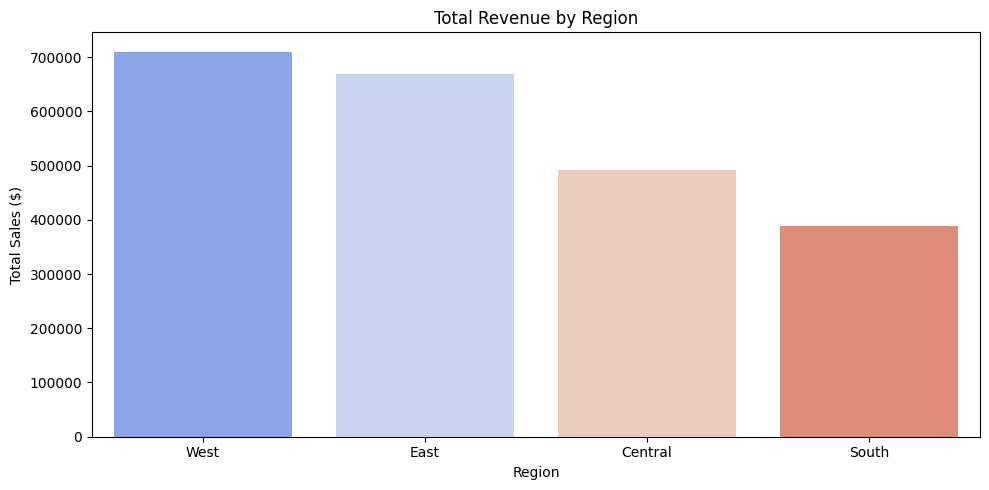

In [12]:
revenue_by_region = df.groupby('Region')['Sales'].sum().reset_index()
revenue_by_region = revenue_by_region.sort_values('Sales', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=revenue_by_region, x='Region', y='Sales', palette='coolwarm')
plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

C:\Users\mouni\AppData\Local\Temp\ipykernel_12496\1157803773.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=revenue_by_segment, x='Segment', y='Sales', palette='Set2')


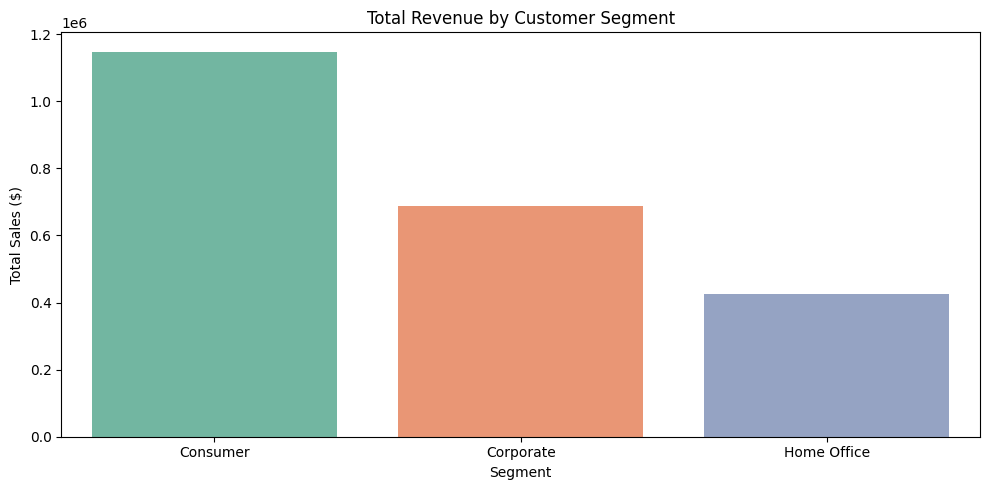

In [13]:
revenue_by_segment = df.groupby('Segment')['Sales'].sum().reset_index()
revenue_by_segment = revenue_by_segment.sort_values('Sales', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=revenue_by_segment, x='Segment', y='Sales', palette='Set2')
plt.title('Total Revenue by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()

In [15]:
import os
os.makedirs('../images', exist_ok=True)

# Chart 1 - Revenue by Year
plt.figure(figsize=(10, 5))
sns.barplot(data=revenue_by_year, x='Year', y='Sales', hue='Year', legend=False)
plt.title('Total Revenue by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('../images/revenue_by_year.png')
plt.close()

# Chart 2 - Revenue by Category
plt.figure(figsize=(10, 5))
sns.barplot(data=revenue_by_category, x='Category', y='Sales', hue='Category', legend=False)
plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('../images/revenue_by_category.png')
plt.close()

# Chart 3 - Top 10 Customers
plt.figure(figsize=(12, 6))
sns.barplot(data=top_customers, x='Sales', y='Customer Name', hue='Customer Name', legend=False)
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Total Sales ($)')
plt.ylabel('Customer Name')
plt.tight_layout()
plt.savefig('../images/top_10_customers.png')
plt.close()

# Chart 4 - Monthly Sales Trend
plt.figure(figsize=(15, 6))
sns.lineplot(data=monthly_sales, x='YearMonth', y='Sales', color='steelblue')
plt.title('Monthly Sales Trend (2015-2018)')
plt.xlabel('Month')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('../images/monthly_sales_trend.png')
plt.close()

# Chart 5 - Revenue by Region
plt.figure(figsize=(10, 5))
sns.barplot(data=revenue_by_region, x='Region', y='Sales', hue='Region', legend=False)
plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('../images/revenue_by_region.png')
plt.close()

# Chart 6 - Revenue by Segment
plt.figure(figsize=(10, 5))
sns.barplot(data=revenue_by_segment, x='Segment', y='Sales', hue='Segment', legend=False)
plt.title('Total Revenue by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('../images/revenue_by_segment.png')
plt.close()

print("All 6 charts saved successfully!")

All 6 charts saved successfully!


In [16]:
readme_content = """# Customer Revenue & Retention Analysis

## Project Overview
This project analyzes 4 years of retail sales data (2015-2018) to uncover revenue trends, top customers, and regional performance using Python.

## Tools Used
- Python 3.12
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

## Dataset
- 9,800 rows of retail transaction data
- Columns include: Order Date, Customer Name, Segment, Region, Category, Sales

## Key Analyses
1. Total Revenue by Year
2. Revenue by Product Category
3. Top 10 Customers by Revenue
4. Monthly Sales Trend (2015-2018)
5. Revenue by Region
6. Revenue by Customer Segment

## Key Findings
- Sales grew consistently from 2015 to 2018
- Technology is the highest revenue generating category
- The West region leads in total sales
- Consumer segment accounts for the largest share of revenue

## Charts
![Revenue by Year](images/revenue_by_year.png)
![Revenue by Category](images/revenue_by_category.png)
![Top 10 Customers](images/top_10_customers.png)
![Monthly Sales Trend](images/monthly_sales_trend.png)
![Revenue by Region](images/revenue_by_region.png)
![Revenue by Segment](images/revenue_by_segment.png)
"""

with open('../README.md', 'w') as f:
    f.write(readme_content)

print("README.md created successfully!")

README.md created successfully!


In [17]:
import subprocess
result = subprocess.run(['git', '--version'], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

git version 2.44.0.windows.1


